In [4]:
import numpy as np
from sympy import *
import matplotlib.pyplot as plt
from sympy.abc import x,y,z
from scipy import optimize #scipy是科学计算库

In [5]:
f_x = -2 * x * exp(-x**2)

In [6]:
f_x

-2*x*exp(-x**2)

In [7]:
f_x_diff = f_x.diff(x)

In [8]:
f_x_diff

4*x**2*exp(-x**2) - 2*exp(-x**2)

In [9]:
f_x_diff_2 = f_x_diff.diff(x)

In [11]:
f_x_diff_2

-8*x**3*exp(-x**2) + 12*x*exp(-x**2)

In [16]:
f_x_diff_2.subs(x,sqrt(2)/2)


4*sqrt(2)*exp(-1/2)

In [17]:
f_x_diff_2.subs(x,-sqrt(2)/2)

-4*sqrt(2)*exp(-1/2)

In [18]:
f_x = -2*x*exp(-x**2)
f_x

-2*x*exp(-x**2)

In [19]:
obj_f = lambdify(x,f_x)

In [23]:
result = optimize.minimize_scalar(obj_f)
print('=====Seccess=====')
print(result.success)
print(result)

=====Seccess=====
True
 message: 
          Optimization terminated successfully;
          The returned value satisfies the termination criteria
          (using xtol = 1.48e-08 )
 success: True
     fun: -0.8577638849607068
       x: 0.7071067808491796
     nit: 11
    nfev: 14


In [25]:
x_min = result.x

x_array = np.linspace(-2,2,100)
y_array = obj_f(x_array)

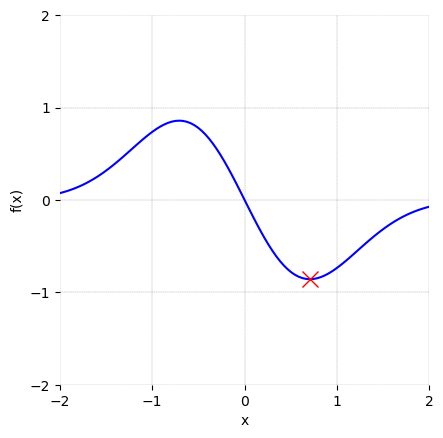

In [29]:
fig,ax = plt.subplots()
plt.plot(x_array,y_array,color = 'b')
plt.plot(x_min,obj_f(x_min),color = 'r',marker = 'x',markersize = 12)

plt.xlabel('x'); plt.ylabel('f(x)')
plt.xticks(np.linspace(-2, 2, 5)); plt.yticks(np.linspace(-2, 2, 5))
plt.axis('scaled')#等比例缩放
ax.set_xlim(-2, 2); ax.set_ylim(-2, 2)
ax.spines['top'].set_visible(False); ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False); ax.spines['right'].set_visible(False)
ax.grid(linestyle='--', linewidth=0.25, color=[0.5, 0.5, 0.5])

In [30]:
f_x_1_diff = diff(f_x,x)
f_x_1_diff

4*x**2*exp(-x**2) - 2*exp(-x**2)

In [31]:
f_x_1_diff_fcn = lambdify(x,f_x_1_diff)
f_x_1_diff_array = f_x_1_diff_fcn(x_array)

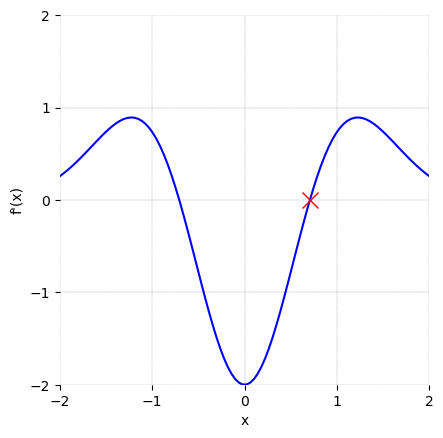

In [33]:
fig,ax = plt.subplots()
plt.plot(x_array,f_x_1_diff_array,color = 'b')
plt.plot(x_min,f_x_1_diff_fcn(x_min),color = 'r',marker = 'x',markersize = 12)
plt.xlabel('x'); plt.ylabel('f\'(x)')
plt.xticks(np.linspace(-2, 2, 5)); plt.yticks(np.linspace(-2, 2, 5))
plt.axis('scaled'); ax.set_xlim(-2, 2); ax.set_ylim(-2, 2)
ax.spines['top'].set_visible(False); ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False); ax.spines['right'].set_visible(False)
ax.grid(linestyle='--', linewidth=0.25, color=[0.5, 0.5, 0.5])

In [38]:
import numpy as np
#第一个:求最小值.后面的是配置条件:线性优化,变量上下限,非线性优化
from scipy.optimize import minimize,LinearConstraint,Bounds,NonlinearConstraint
import matplotlib.pyplot as plt

In [39]:
def obj_f(x):
    x1 = x[0]
    x2 = x[1]
    obj = -2 *x1 *np.exp(-x1**2 - x2**2)
    return obj

In [40]:
x0 = [1,1]

In [41]:
def nonlinear_c(x):
    x1 = x[0]
    x2 = x[1]
    nlc = np.abs(x1) + np.abs(x2 + 1) - 1
    return nlc

In [43]:
#NonlinearConstraint接受的是一个nonlinear_c的python函数
#后两个参数表示函数的下界和上界-oo表示没有下限,表示函数的取值范围
nlc = NonlinearConstraint(nonlinear_c,-np.inf,0) 

In [45]:
bounds = Bounds([-1.5,-1.5],[1.5,1.5])

In [53]:
res = minimize(obj_f,x0,
               method = 'trust-constr',#信赖域优化算法
               bounds = bounds,
               constraints = [nlc])
optimized_x = res.x

In [54]:
print('====optimal solution====')
print(res.x)

====optimal solution====
[ 0.49999999 -0.50000001]


In [55]:
print('====optimal objective====')
print(res.fun)

====optimal objective====
-0.6065306494726295


In [56]:
num = 201
rr = np.linspace(-2,2,num)
xx1,xx2 = np.meshgrid(rr,rr)

yy = obj_f(np.vstack([xx1.ravel(),xx2.ravel()])).reshape(num,num)

(-2.0, 2.0)

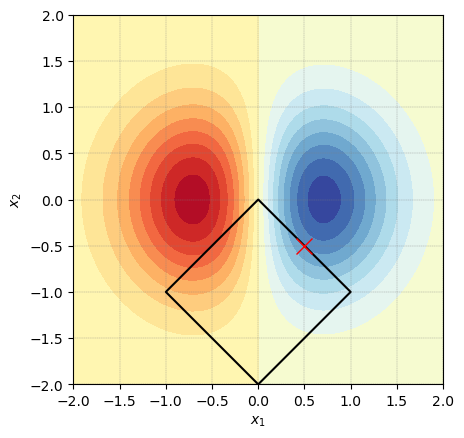

In [60]:
fig,ax = plt.subplots()

ax.contourf(xx1,xx2,yy,levels = 20,cmap = 'RdYlBu_r')

yy_nlc = nonlinear_c(np.vstack([xx1.ravel(),xx2.ravel()])).reshape((num,num))
ax.contour(xx1,xx2,yy_nlc,levels = [0],colors = 'k')

plt.plot(optimized_x[0],optimized_x[1],'rx',markersize = 12)

ax.set_xlabel('$\it{x}_1$')  # 设置 x 轴标签
ax.set_ylabel('$\it{x}_2$')  # 设置 y 轴标签
ax.axis('square')
ax.grid(linestyle='--', linewidth=0.25, color=[0.5, 0.5, 0.5])
ax.set_xlim([rr.min(), rr.max()])
ax.set_ylim([rr.min(), rr.max()])